https://github.com/abhisheksuran/Reinforcement_Learning/blob/master/SoftAC.ipynb

In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [ ]:
from variable_print import p,ps,pst

In [ ]:
%%time
%%capture
!pip install swig
!pip install gymnasium[box2d] ## python 3.11은 gym[box2d]문제 있음
import gymnasium as gym  ###

CPU times: user 233 ms, sys: 25 ms, total: 258 ms
Wall time: 50.4 s


In [ ]:
import tensorflow as tf
import keras
from keras import layers
from keras.models import load_model
import tensorflow_probability as tfp
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

## Env

In [ ]:
env= gym.make("LunarLanderContinuous-v2")
state_low = env.observation_space.low
state_high = env.observation_space.high
action_low = env.action_space.low
action_high = env.action_space.high
print('1 :', state_low)
print('2 :', state_high)
print('3 :', action_low)
print('4 :', action_high)
env.close()

1 : [-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ]
2 : [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ]
3 : [-1. -1.]
4 : [1. 1.]


## Replay Buffer

In [ ]:
class RBuffer():
  def __init__(self, maxsize, statedim, naction):
    self.cnt = 0
    self.maxsize = maxsize
    self.state_memory = np.zeros((maxsize, *statedim), dtype=np.float32)
    self.action_memory = np.zeros((maxsize, naction), dtype=np.float32)
    self.reward_memory = np.zeros((maxsize,), dtype=np.float32)
    self.next_state_memory = np.zeros((maxsize, *statedim), dtype=np.float32)
    self.done_memory = np.zeros((maxsize,), dtype= bool)

  def storexp(self, state, next_state, action, done, reward):
    index = self.cnt % self.maxsize
    self.state_memory[index] = state
    self.action_memory[index] = action
    self.reward_memory[index] = reward
    self.next_state_memory[index] = next_state
    self.done_memory[index] = 1.- int(done)
    self.cnt += 1

  def sample(self, batch_size):
    max_mem = min(self.cnt, self.maxsize)
    batch = np.random.choice(max_mem, batch_size, replace= False)
    states = tf.convert_to_tensor(self.state_memory[batch])
    next_states = tf.convert_to_tensor(self.next_state_memory[batch])
    rewards = tf.convert_to_tensor(self.reward_memory[batch])
    actions = tf.convert_to_tensor(self.action_memory[batch])
    dones = tf.convert_to_tensor(self.done_memory[batch],dtype=tf.float32)
    return states, next_states, rewards, actions, dones


## Actor Critic Network

In [ ]:
hidden = 256
n_actions = len(env.action_space.high)
state_shape = env.observation_space.low.shape #(8,)
action_shape = env.action_space.high.shape    #(2,)

def Actor():
   input_s = layers.Input(shape=state_shape)
   x = layers.Dense(hidden)(input_s)
   x = layers.BatchNormalization()(x)
   x = layers.Activation('relu')(x)
   x = layers.Dense(hidden, activation='relu')(x)
   mu = layers.Dense(action_shape[0], activation='linear')(x)
   log_sigma = layers.Dense(action_shape[0], activation='linear')(x)
   sigma = layers.Lambda(lambda x: tf.math.exp(x))(log_sigma)
   return keras.Model(inputs=input_s, outputs=[mu, sigma],name="actor")

def Critic():
    input_s = layers.Input(shape=state_shape)
    input_a = layers.Input(shape=action_shape)
    inputs = layers.concatenate([input_s, input_a])
    x = layers.Dense(hidden)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dense(hidden, activation='relu')(x)
    x = layers.Dense(1, activation='linear')(x)
    return keras.Model(inputs=[input_s, input_a], outputs=x,name="critic")

def value_net():
    input_s = layers.Input(shape=state_shape)
    x = layers.Dense(hidden)(input_s)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dense(hidden, activation='relu')(x)
    x = layers.Dense(1, activation='linear')(x)
    return keras.Model(inputs=input_s, outputs=x,name="Vnet")

In [ ]:
actor = Actor()
critic = Critic()
v_net = value_net()
actor.summary(line_length=60,)
critic.summary(line_length=60)
v_net.summary(line_length=60)

Model: "actor"

┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)    ┃ Output Shape ┃ Param # ┃ Connected to  ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_32  │ (None, 8)    │       0 │ -             │
│ (InputLayer)    │              │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ dense_74        │ (None, 256)  │   2,304 │ input_layer_… │
│ (Dense)         │              │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ batch_normaliz… │ (None, 256)  │   1,024 │ dense_74[0][… │
│ (BatchNormaliz… │              │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ activation_23   │ (None, 256)  │       0 │ batch_normal… │
│ (Activation)    │              │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ dense_75        │ (None, 256)  │  65,792 │ activation_2… │
│ (Dense)         │              │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ dense_77        │ (None, 2)    │     514 │ dense_75[0][… │
│ (Dense)         │              │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ dense_76        │ (None, 2)    │     514 │ dense_75[0][… │
│ (Dense)         │              │         │               │
├─────────────────┼──────────────┼─────────┼───────────────┤
│ lambda_5        │ (None, 2)    │       0 │ dense_77[0][… │
│ (Lambda)        │              │         │               │
└─────────────────┴──────────────┴─────────┴───────────────┘

 Total params: 70,148 (274.02 KB)

 Trainable params: 69,636 (272.02 KB)

 Non-trainable params: 512 (2.00 KB)

...

Model: "Vnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ input_layer_35           │ (None, 8)         │         0 │
│ (InputLayer)             │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_81 (Dense)         │ (None, 256)       │     2,304 │
├──────────────────────────┼───────────────────┼───────────┤
│ batch_normalization_25   │ (None, 256)       │     1,024 │
│ (BatchNormalization)     │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ activation_25            │ (None, 256)       │         0 │
│ (Activation)             │                   │           │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_82 (Dense)         │ (None, 256)       │    65,792 │
├──────────────────────────┼───────────────────┼───────────┤
│ dense_83 (Dense)         │ (None, 1)         │       257 │
└──────────────────────────┴───────────────────┴───────────┘

 Total params: 69,377 (271.00 KB)

 Trainable params: 68,865 (269.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
#keras.utils.plot_model(actor, show_shapes=True, show_layer_names=False, dpi=70)
#keras.utils.plot_model(critic, show_shapes=True, show_layer_names=False, dpi=70)
#keras.utils.plot_model(value_net, show_shapes=True, show_layer_names=False, dpi=70)

In [ ]:
batch_size = 256 #64
n_RM = 100_000
a_lr = 0.0001
c_lr = 0.0002
tau = 0.1

@keras.saving.register_keras_serializable()
class Agent(keras.Model):
  def __init__(self, n_action= len(env.action_space.high),*args,**kwargs):
    super(Agent, self).__init__(*args, **kwargs)
    global batch_size, n_RM, a_lr, c_lr
    self.actor_main = Actor()
    self.critic_1 = Critic()
    self.critic_2 = Critic()
    self.value_net = value_net()
    self.target_value_net = value_net()
    self.target_value_net.set_weights(self.value_net.get_weights())##

    self.batch_size = batch_size
    self.n_actions = len(env.action_space.high)
    self.a_opt = tf.keras.optimizers.Adam(a_lr)
    self.c_opt1 = tf.keras.optimizers.Adam(c_lr)
    self.c_opt2 = tf.keras.optimizers.Adam(c_lr)
    self.v_opt = tf.keras.optimizers.Adam(c_lr)
    self.memory = RBuffer(n_RM, env.observation_space.shape, len(env.action_space.high))
    self.trainstep = 0
    self.gamma = 0.99
    self.tau = tau
    self.min_action = env.action_space.low[0]
    self.max_action = env.action_space.high[0]
    self.scale = 2

  def savexp(self,state, next_state, action, done, reward):
        self.memory.storexp(state, next_state, action, done, reward)

  @tf.function
  def train(self, states, next_states, rewards, actions, dones):
      with tf.GradientTape(persistent=True) as tape:
          #value loss
          value = tf.squeeze(self.value_net(states)) # v(s)
          v_actions, v_log_pi = self.sample_normal(states)
          v_actions = tf.clip_by_value(v_actions, self.min_action, self.max_action)
          v_q1 = self.critic_1((states, v_actions))
          v_q2 = self.critic_2((states, v_actions))
          v_critic_value = tf.math.minimum(tf.squeeze(v_q1), tf.squeeze(v_q2))
          target_value = v_critic_value - v_log_pi  # vt(s)= min(Q(s,a))-log(pi(a|s))
          value_loss = 0.5 * tf.keras.losses.MSE(target_value, value)
          #actor loss
          a_actions, a_log_pi = self.sample_normal(states)
          a_q1 = self.critic_1((states, a_actions))
          a_q2 = self.critic_2((states, a_actions))
          a_critic_value = tf.math.minimum(tf.squeeze(a_q1), tf.squeeze(a_q2))
          actor_loss =  a_log_pi - a_critic_value # log(pi)(=-H) - Q
          actor_loss = tf.reduce_mean(actor_loss)
          #critic loss
          next_state_value = tf.squeeze(self.target_value_net(next_states))
          q_hat = self.scale * rewards + self.gamma * next_state_value * dones
          c_q1 = self.critic_1((states, actions))
          c_q2 = self.critic_2((states, actions))
          critic_loss1 = 0.5 * tf.keras.losses.MSE(q_hat, tf.squeeze(c_q1))
          critic_loss2 = 0.5 * tf.keras.losses.MSE(q_hat, tf.squeeze(c_q2))
          Q_loss = critic_loss1 + critic_loss2
      grads1 = tape.gradient(value_loss, self.value_net.trainable_variables)
      grads2 = tape.gradient(actor_loss, self.actor_main.trainable_variables)
      grads3 = tape.gradient(critic_loss1, self.critic_1.trainable_variables)
      grads4 = tape.gradient(critic_loss2, self.critic_2.trainable_variables)
      self.v_opt.apply_gradients(zip(grads1, self.value_net.trainable_variables))
      self.a_opt.apply_gradients(zip(grads2, self.actor_main.trainable_variables))
      self.c_opt1.apply_gradients(zip(grads3, self.critic_1.trainable_variables))
      self.c_opt2.apply_gradients(zip(grads4, self.critic_2.trainable_variables))
      self.trainstep +=1
      self.update_target(self.target_value_net, self.value_net)
      return Q_loss,actor_loss,value_loss,tf.reduce_mean(a_log_pi),tf.reduce_mean(a_critic_value)

  @tf.function
  def update_target(self, target_model, source_model):
      for target_var, source_var in zip(target_model.trainable_variables,\
                                        source_model.trainable_variables):
          target_var.assign(self.tau * source_var + (1 - self.tau) * target_var)

  @tf.function
  def sample_normal(self, state):
    mu, sigma = self.actor_main(state)
    normal = tfp.distributions.Normal(mu, sigma)
    actions  = normal.sample()     #u = mu + sigma*epsilon
    action = tf.math.tanh(actions) #a=tanh(u)
    action = tf.squeeze(action)
    log_pi = normal.log_prob(actions)
    log_pi -= tf.math.log(1 - tf.math.pow(action, 2) + 1e-6)
    log_pi = tf.reduce_sum(log_pi, axis=1)
    return action, log_pi

## Train

In [ ]:
#%%time
env= gym.make("LunarLanderContinuous-v2")
agent = Agent()

episods = 50 #300
ep_rewards = []
avg_rewards = []
losses = [[0,0,0,0,0]]
target = False
total_avgr_best = -300

for epis in range(episods):
  ep_reward = 0
  ep_step = 0
  done = False
  state, _ = env.reset()
  while (not done) :#and (ep_step < max_steps) :
    action, _ = agent.sample_normal(state[tf.newaxis,...])
    next_state, reward, done, _, _ = env.step(action)
    agent.savexp(state, next_state, action, done, reward)
    state = next_state
    ep_reward += reward
    ep_step += 1
    if agent.memory.cnt > agent.batch_size:
      states, next_states, rewards, actions, dones = agent.memory.sample(agent.batch_size)
      losses.append(agent.train(states, next_states, rewards, actions, dones))
      losses.append(agent.train(states, next_states, rewards, actions, dones))
      losses.append(agent.train(states, next_states, rewards, actions, dones))
      losses.append(agent.train(states, next_states, rewards, actions, dones))
      losses.append(agent.train(states, next_states, rewards, actions, dones))
    if done:
      ep_rewards.append(ep_reward)
      avg_rewards.append(np.mean(ep_rewards[-10:]))
      print(f"Episodes(steps):{epis:03d}({ep_step:03d}), Rewards(average):{ep_reward:3.1f}({avg_rewards[-1]:3.1f})",end="")
      last_losses = losses[-1]
      print(f",\t Loss:: Q:{last_losses[0]:.3f}, A:{last_losses[1]:.3f}, V:{last_losses[2]:.5f}, ",end="")
      print(f"-log_pi:{last_losses[3]:.3f}, Q_target:{last_losses[4]:.3f})",end="")
      print(f",\t Buffer.cnt:{agent.memory.cnt}")
#   if total_avgr_best < avg_rewards[-1] :
#     total_avgr_best = avg_rewards[-1]
#     # Save the weights
#     agent.save(path+"models/DRL/SoftAC.keras")
#     print(f'Model Saved.')
#   if avg_rewards[-1] > 100: break #150

# agent = keras.models.load_model(path+"/models/DRL/SoftAC.keras")
# env.close()

Episodes(steps):000(108), Rewards(average):-290.3(-290.3),	 Loss:: Q:0.000, A:0.000, V:0.00000, -log_pi:0.000, Q_target:0.000),	 Buffer.cnt:108
Episodes(steps):001(092), Rewards(average):-59.7(-175.0),	 Loss:: Q:0.000, A:0.000, V:0.00000, -log_pi:0.000, Q_target:0.000),	 Buffer.cnt:200
Episodes(steps):002(092), Rewards(average):-215.5(-188.5),	 Loss:: Q:282.777, A:10.033, V:0.62808, -log_pi:-1.160, Q_target:-11.192),	 Buffer.cnt:292
Episodes(steps):003(163), Rewards(average):-186.9(-188.1),	 Loss:: Q:12.107, A:19.247, V:1.92545, -log_pi:0.740, Q_target:-18.508),	 Buffer.cnt:455
Episodes(steps):004(243), Rewards(average):-8.3(-152.1),	 Loss:: Q:62.899, A:-27.761, V:4.09787, -log_pi:0.485, Q_target:28.246),	 Buffer.cnt:698
Episodes(steps):005(1000), Rewards(average):61.5(-116.5),	 Loss:: Q:27.844, A:-107.439, V:3.01439, -log_pi:0.303, Q_target:107.742),	 Buffer.cnt:1698
Episodes(steps):006(1000), Rewards(average):37.6(-94.5),	 Loss:: Q:6.626, A:-104.160, V:1.64663, -log_pi:-0.410, Q_targ

Episodes(steps):058(323), Rewards(average):283.3(108.4)  : Wall time: 5min 12s    
Episodes(steps):149(1000), Rewards(average):128.1(100.8) : Wall time: 19min 28s  
Episodes(steps):136(284), Rewards(average):267.4(158.4)  : Wall time: 25min 1s  



```python
Episodes(steps):000(116), Rewards(average):-189.9(-189.9)
Episodes(steps):005(157), Rewards(average):-100.2(-159.3)
Episodes(steps):010(1000), Rewards(average):75.8(-150.7)
Episodes(steps):015(1000), Rewards(average):130.3(-85.4)
Episodes(steps):020(1000), Rewards(average):-2.5(-54.5)
...  
Episodes(steps):100(1000), Rewards(average):96.4(91.6)
Episodes(steps):105(1000), Rewards(average):75.7(79.8)
Episodes(steps):110(1000), Rewards(average):145.3(88.8)
Episodes(steps):115(1000), Rewards(average):75.9(90.6)
Episodes(steps):120(788), Rewards(average):-49.5(74.5)
...
Episodes(steps):200(1000), Rewards(average):79.7(129.8)
Episodes(steps):205(1000), Rewards(average):159.4(126.3)
Episodes(steps):210(138), Rewards(average):11.6(124.2)
Episodes(steps):215(1000), Rewards(average):119.7(122.9)
Episodes(steps):220(1000), Rewards(average):116.5(118.1)
...
Episodes(steps):275(1000), Rewards(average):119.9(126.2)
Episodes(steps):280(1000), Rewards(average):110.6(126.3)
Episodes(steps):285(1000), Rewards(average):102.5(125.9)
Episodes(steps):290(084), Rewards(average):13.2(108.8)
Episodes(steps):295(1000), Rewards(average):141.0(104.0)
Episodes(steps):299(1000), Rewards(average):163.1(106.6)
```

In [ ]:
#p(losses[0:2])

In [ ]:
np_losses = np.array(losses[1:])
def ma(a, n=10):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

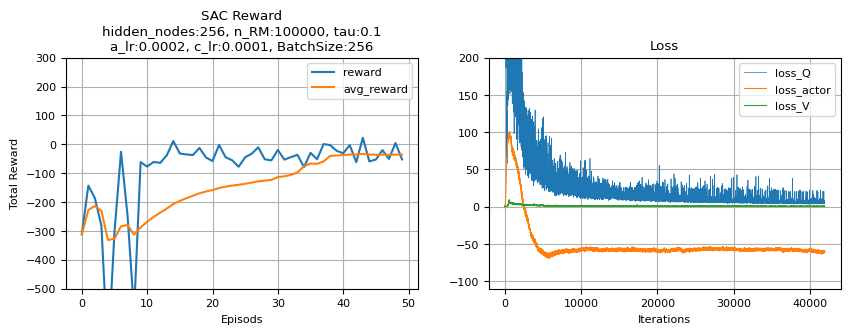

In [ ]:
conditions = f'hidden_nodes:{hidden}, n_RM:{n_RM}, tau:{agent.tau}\n\
a_lr:{c_lr}, c_lr:{a_lr}, BatchSize:{batch_size}'

plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title(f"SAC Reward\n{conditions}")
plt.plot(ep_rewards,label='reward')
plt.plot(avg_rewards,label='avg_reward')
plt.xlabel("Episods")
plt.ylabel("Total Reward")
plt.ylim(-500,300)
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(ma(np_losses[:,0]),label='loss_Q',linewidth=0.5)
plt.plot(ma(np_losses[:,1]),label='loss_actor',linewidth=0.8)
plt.plot(ma(np_losses[:,2]),label='loss_V',linewidth=0.8)
plt.title("Loss")
plt.xlabel("Iterations")
plt.ylim(-110,200)
plt.grid()
plt.legend()
plt.show()
plt.show()

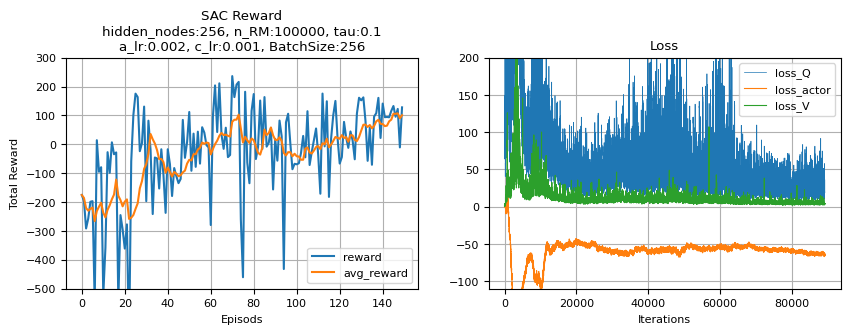

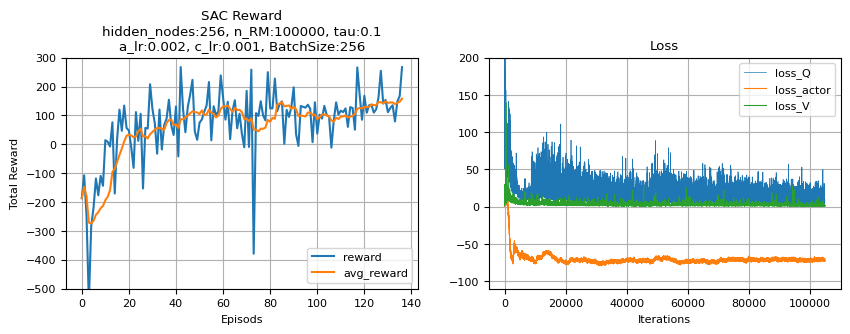

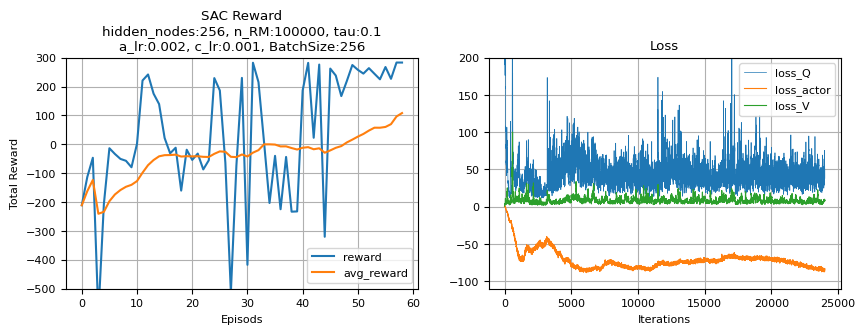

In [ ]:
# Load Model
agent = Agent()
save_path = path+"models/DRL/SoftAC.keras"
agent = keras.models.load_model(save_path)

In [ ]:
env= gym.make("LunarLanderContinuous-v2")


In [ ]:
total_reward = 0
state, _ = env.reset()
done = False
while not done:
    action = agent.sample_normal(state[tf.newaxis,...])[0].numpy()
    next_state, reward, done, info, _, _ = env.step(action)
    state = next_state
    total_reward += reward
    if done:
       print(total_reward)

-106.44509376637953


In [ ]:
%%capture
!pip install gym pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env_v3, render_as_image_v3

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env_v3(env, path=path, name_prefix="SoftAC-LundarLander")
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image_v3(env_v,step=cnt)
    action = agent.sample_normal(state[tf.newaxis,...])[0].numpy()
    next_state, reward, done, info = env_v.step(action)
    state = next_state
    if done or cnt > 600:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='SoftAC-LundarLander')

/content/gdrive/MyDrive/Colab Notebooks/video/SoftAC-LundarLander-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='SoftAC-LundarLander')

/content/gdrive/MyDrive/Colab Notebooks/video/SoftAC-LundarLander-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='SoftAC-LundarLander')

/content/gdrive/MyDrive/Colab Notebooks/video/SoftAC-LundarLander-episode-0.mp4
